In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:


df = pd.read_excel("all_article_data.xlsx")



In [3]:
df

,row_id,paper_id,year,inhibitor,substrate,acid_type,acid_molarity_M,temperature_K,immersion_time_min,qe_concentration_ppm,method,IE_percent,is_blank,row_flag,source_table,notes
0,1,P1,2023,QE,St37,HCl,1,298,30,0,polarization,0.0,Yes,ok,P1_Table2,blank standardized to 0 ppm
1,2,P1,2023,QE,St37,HCl,1,298,30,200,polarization,67.8,No,ok,P1_Table2,NaN
2,3,P1,2023,QE,St37,HCl,1,298,30,400,polarization,69.0,No,ok,P1_Table2,NaN
3,4,P1,2023,QE,St37,HCl,1,298,30,600,polarization,79.5,No,ok,P1_Table2,NaN
4,5,P1,2023,QE,St37,HCl,1,298,30,800,polarization,90.4,No,ok,P1_Table2,NaN
5,6,P1,2023,QE,St37,HCl,1,298,30,1000,polarization,91.3,No,ok,P1_Table2,NaN
6,7,P1,2023,QE,St37,HCl,1,298,30,1200,polarization,95.0,No,ok,P1_Table2,max polarization IE in P1
7,8,P1,2023,QE,St37,HCl,1,298,30,0,EIS,0.0,Yes,ok,P1_Table3,blank standardized to 0 ppm
8,9,P1,2023,QE,St37,HCl,1,298,30,200,EIS,70.1,No,ok,P1_Table3,NaN
9,10,P1,2023,QE,St37,HCl,1,298,30,400,EIS,76.8,No,ok,P1_Table3,NaN


In [4]:
df1= pd.read_excel("clean_article_data.xlsx")

In [5]:
df1

,row_id,paper_id,year,inhibitor,substrate,acid_type,acid_molarity_M,temperature_K,immersion_time_min,qe_concentration_ppm,method,IE_percent,is_blank,row_flag,source_table,notes
0,1,P1,2023,QE,St37,HCl,1,298,30,0,polarization,0.0,Yes,ok,P1_Table2,blank standardized to 0 ppm
1,2,P1,2023,QE,St37,HCl,1,298,30,200,polarization,67.8,No,ok,P1_Table2,NaN
2,3,P1,2023,QE,St37,HCl,1,298,30,400,polarization,69.0,No,ok,P1_Table2,NaN
3,4,P1,2023,QE,St37,HCl,1,298,30,600,polarization,79.5,No,ok,P1_Table2,NaN
4,5,P1,2023,QE,St37,HCl,1,298,30,800,polarization,90.4,No,ok,P1_Table2,NaN
5,6,P1,2023,QE,St37,HCl,1,298,30,1000,polarization,91.3,No,ok,P1_Table2,NaN
6,7,P1,2023,QE,St37,HCl,1,298,30,1200,polarization,95.0,No,ok,P1_Table2,max polarization IE in P1
7,8,P1,2023,QE,St37,HCl,1,298,30,0,EIS,0.0,Yes,ok,P1_Table3,blank standardized to 0 ppm
8,9,P1,2023,QE,St37,HCl,1,298,30,200,EIS,70.1,No,ok,P1_Table3,NaN
9,10,P1,2023,QE,St37,HCl,1,298,30,400,EIS,76.8,No,ok,P1_Table3,NaN


In [6]:
df1["method_code"] = df1["method"].map({"polarization": 0,"EIS": 1})

In [7]:
X= df1[['temperature_K','qe_concentration_ppm','method_code']]

In [8]:
y= df1['IE_percent']

In [9]:
X

,temperature_K,qe_concentration_ppm,method_code
0,298,0,0
1,298,200,0
2,298,400,0
3,298,600,0
4,298,800,0
5,298,1000,0
6,298,1200,0
7,298,0,1
8,298,200,1
9,298,400,1


In [10]:
y

0      0.0
1     67.8
2     69.0
3     79.5
4     90.4
5     91.3
6     95.0
7      0.0
8     70.1
9     76.8
10    81.3
11    82.4
12    87.0
13    93.0
14     0.0
15    69.0
16    81.0
17    87.0
18    91.0
19     0.0
20    72.0
21    79.0
22    85.0
23     0.0
24    56.0
25    74.0
26    81.0
27     0.0
28    68.9
29    77.0
30    85.7
31    88.5
32     0.0
33    61.2
34    76.0
35    77.9
36     0.0
37    47.0
38    69.1
39    75.0
40    78.0
Name: IE_percent, dtype: float64

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=101)

In [12]:
X_train

,temperature_K,qe_concentration_ppm,method_code
27,308,0,1
7,298,0,1
35,318,1000,1
22,318,1000,0
10,298,600,1
3,298,600,0
34,318,800,1
29,308,600,1
24,328,400,0
2,298,400,0


In [13]:
y_train

27     0.0
7      0.0
35    77.9
22    85.0
10    81.3
3     79.5
34    76.0
29    77.0
24    56.0
2     69.0
36     0.0
15    69.0
19     0.0
38    69.1
30    85.7
12    87.0
5     91.3
14     0.0
0      0.0
28    68.9
21    79.0
8     70.1
40    78.0
4     90.4
13    93.0
9     76.8
39    75.0
23     0.0
6     95.0
17    87.0
11    82.4
31    88.5
Name: IE_percent, dtype: float64

In [14]:
lm=LinearRegression()

In [15]:
lm.fit(X_train,y_train)

LinearRegression()

In [16]:
pred_lm=lm.predict(X_test)

In [17]:
pred_lm

array([93.15699151, 62.95220522, 40.67934412, 68.81678364, 83.91917679,
       15.09346519, 58.33329786, 37.36632629, 45.29825148])

In [18]:
y_test

18    91.0
16    81.0
37    47.0
25    74.0
26    81.0
32     0.0
20    72.0
1     67.8
33    61.2
Name: IE_percent, dtype: float64

In [19]:
mae=mean_absolute_error(y_test,pred_lm)
print('MAE:',mae)

MAE: 12.191491652707915


In [20]:
rmse=np.sqrt(mean_squared_error(y_test,pred_lm))
print('RMSE:',rmse)

RMSE: 14.904805581066412


In [21]:
r2=r2_score(y_test,pred_lm)
print('R2:',r2)

R2: 0.6598636237785224


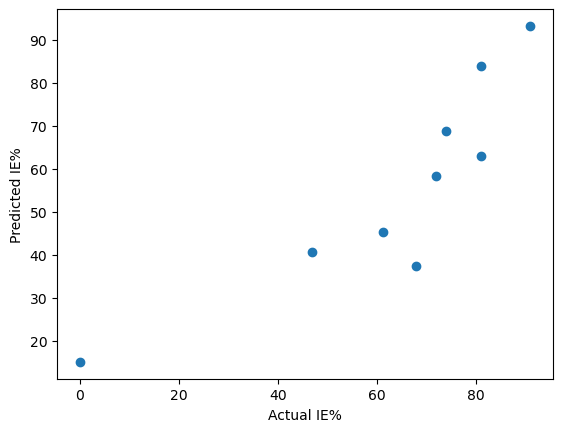

In [22]:
plt.scatter(y_test, pred_lm)
plt.xlabel('Actual IE%')
plt.ylabel('Predicted IE%')
plt.show()

In [23]:
lm.score(X_test,y_test)

0.6598636237785224

### RandomForest

In [24]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
rfr=RandomForestRegressor()

In [26]:
rfr.fit(X_train,y_train)

RandomForestRegressor()

In [27]:
pred_rf=rfr.predict(X_test)

In [28]:
rfr.score(X_test,y_test)

0.8415284287321524

In [29]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [30]:
print('MAE:',mean_absolute_error(y_test,pred_rf))

MAE: 7.024222222222218


In [31]:
print('MSE:',mean_squared_error(y_test,pred_rf))

MSE: 103.50251777777778


In [32]:
print('RMSE:',np.sqrt(mean_squared_error(y_test,pred_rf)))

RMSE: 10.17361871596227


### XGBoost

In [33]:
from xgboost import XGBRegressor

In [34]:
xgb=XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=101)

In [35]:
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=101, ...)

In [36]:
pred_xgb=xgb.predict(X_test)

In [37]:
xgb.score(X_test,y_test)

0.9736788027166413

In [38]:
print('Model Score R2:', xgb.score(X_test, y_test))
print('MAE:', mean_absolute_error(y_test, pred_xgb))
print('MSE:', mean_squared_error(y_test, pred_xgb))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_xgb)))
print('R2:', r2_score(y_test, pred_xgb))

Model Score R2: 0.9736788027166413
MAE: 2.5459831747743826
MSE: 17.191160332149522
RMSE: 4.1462224171104864
R2: 0.9736788027166413


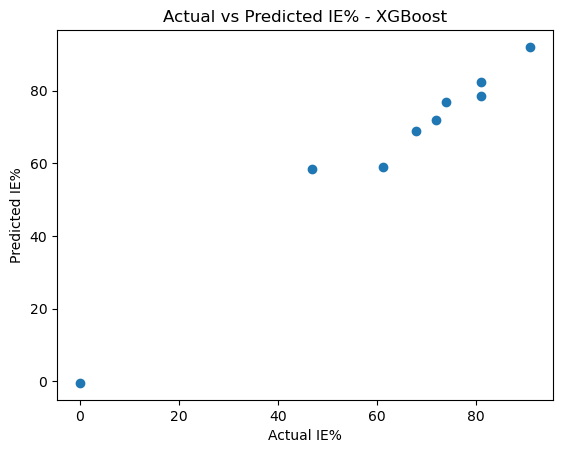

In [39]:
plt.scatter(y_test, pred_xgb)
plt.xlabel("Actual IE%")
plt.ylabel("Predicted IE%")
plt.title("Actual vs Predicted IE% - XGBoost")
plt.show()

In [40]:
def get_metrics(model_name,y_test,predictions):
    return {'model':model_name,
            'MAE':mean_absolute_error(y_test,predictions),
            'MSE':mean_squared_error(y_test,predictions),
            'RMSE':np.sqrt(mean_squared_error(y_test,predictions)),
            'R2':r2_score(y_test,predictions)}

In [41]:
results=[]
results.append(get_metrics('Linear Regression',y_test,pred_lm))
results.append(get_metrics('Random Forest',y_test,pred_rf))
results.append(get_metrics('XGBoost',y_test,pred_xgb))

In [44]:
results_df=pd.DataFrame(results)
results_df=results_df.round(3)

In [45]:
results_df

,model,MAE,MSE,RMSE,R2
0,Linear Regression,12.191,222.153,14.905,0.660
1,Random Forest,7.024,103.503,10.174,0.842
2,XGBoost,2.546,17.191,4.146,0.974
